<a href="https://colab.research.google.com/github/jangInw007/BSC_DPDM2025/blob/main/Midterm_663020278_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ข้อ1 อ่านไฟล์ทั้งหมด แสดงโครงสร้างข้อมูล และอธิบายความหมายของแต่ละคอลัม

#import data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##อ่านไฟล์ทุกเดือน 7–12 ทีเดียว

✅ ใช้ glob ครอบทุกโฟลเดอร์

In [121]:
import glob
import pandas as pd

base_path = '/content/drive/MyDrive/BSC DPDM midterm 2025/Input - (Operation Daily rain from API_ 2025)/'

files = []
for month in range(7, 13):  # Iterate through months 7 to 12
    month_str = f"{month:02d}"  # Format month with leading zero (e.g., '07', '08')

    # Construct a specific glob pattern for each month to target the expected daily rainfall files
    # This assumes filenames follow 'HII_daily_rainfall_2025-MM-DD.csv' format within '2025-MM' folders.
    # The '??' wildcard is used for the day part, trusting valid days exist.
    pattern = f"{base_path}2025-{month_str}/HII_daily_rainfall_2025-{month_str}-??.csv"
    files.extend(glob.glob(pattern))

files = sorted(list(set(files))) # Ensure uniqueness and sort the file paths
len(files)

184

## รวมทุกไฟล์เป็น daily rainfall เดียว

In [241]:
df_list = []

for f in files:
    df = pd.read_csv(f)

    # ดึงวันที่จากชื่อไฟล์
    date = f.split('_')[-1].replace('.csv', '')
    df['date'] = pd.to_datetime(date)

    df_list.append(df)

rain = pd.concat(df_list, ignore_index=True)
rain.head()

,rainfall_datetime,rainfall_datetime_calc,rainfall_value,tele_station_id,tele_station_oldcode,measure_datetime,date
0,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.0,589.0,MWOG,2025-07-01,2025-07-01
1,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.0,564.0,MSRM,2025-07-01,2025-07-01
2,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,34.0,4.0,CPY015,2025-07-01,2025-07-01
3,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.2,867.0,KMSI,2025-07-01,2025-07-01
4,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,38.2,54.0,CPY016,2025-07-01,2025-07-01


In [238]:
rain.shape

(176886, 7)


ดูว่า date มีเดือนไหนบ้าง และแต่ละเดือนมีวันอะไรบ้าง

In [124]:
rain['month'] = rain['date'].dt.month
rain['day'] = rain['date'].dt.day

for month in sorted(rain['month'].unique()):
    print(f"Month: {month}")
    days_in_month = sorted(rain[rain['month'] == month]['day'].unique())
    print(f"  Days: {days_in_month}")

Month: 7
  Days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]
Month: 8
  Days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]
Month: 9
  Days: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.in

In [125]:
rain.isnull().sum()

,0
rainfall_datetime,0
rainfall_datetime_calc,0
rainfall_value,4
tele_station_id,3814
tele_station_oldcode,8865
measure_datetime,0
date,0
month,0
day,0


**ตาราง rain มีคอลัมน์ ดังนี้**

1. rainfall_datetime	เวลา timestamp ของข้อมูล

2. rainfall_datetime_calc	เวลาในรูปแบบ ISO (ระบบ)

3. rainfall_value	ปริมาณฝนรายวัน (mm)

4. tele_station_id	รหัสสถานีเชิงระบบ

5. tele_station_oldcode	รหัสสถานี (Node)

6. measure_datetime	วันที่วัดฝนจริง

7. date	วันที่สำหรับวิเคราะห์

8. month เดือน

9. day วัน

# ข้อ2. กรองข้อมูลให้เหลือเฉพาะสถานีใน Stations in the model_HII.csv แสดงจำนวนสถานีก่อน/หลัง

##กรองเฉพาะสถานีใน station in the model_HII.csv

In [242]:
stations = pd.read_csv('/content/drive/MyDrive/BSC DPDM midterm 2025/Input - (Operation Daily rain from API_ 2025)/Stations in the model_HII.csv')
stations

,Node,Lat,Long
0,ACRU,15.788054,104.642235
1,BBHN,9.536913,98.579490
2,BBUA,17.372976,103.984436
3,BCNG,17.386840,103.290870
4,BDAR,14.587073,102.495190
...,...,...,...
380,YOM003,18.265924,100.177060
381,YOM008,16.708166,100.171780
382,YOM009,16.310750,100.271750
383,YOM010,18.133717,100.124596


In [243]:
num_stations = stations['Node'].nunique()
print(f"stations มี {num_stations} สถานี")

stations มี 385 สถานี


เลือกแถวใน rain ที่มีข้อมูลในคอลัม tele_station_oldcode ตรงกับ Node ของ stations โดยยึด Node ของ stations เป็นหลัก

## สถานีก่อนกรอง

In [244]:
stations_before = rain['tele_station_oldcode'].nunique()
print(f"stations ก่อนกรอง มี {stations_before} สถานี")

stations ก่อนกรอง มี 1514 สถานี


In [245]:
rain_filtered = rain[rain['tele_station_oldcode'].isin(stations['Node'])]
print(f"Number of matching entries: {len(rain_filtered)}")
print("Head of filtered 'rain' DataFrame:")
rain_filtered

Number of matching entries: 66275
Head of filtered 'rain' DataFrame:


,rainfall_datetime,rainfall_datetime_calc,rainfall_value,tele_station_id,tele_station_oldcode,measure_datetime,date
2,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,34.0,4.0,CPY015,2025-07-01,2025-07-01
3,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.2,867.0,KMSI,2025-07-01,2025-07-01
7,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.0,305.0,CSMO,2025-07-01,2025-07-01
8,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.0,857.0,NPCT,2025-07-01,2025-07-01
10,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,44.0,339.0,KON005,2025-07-01,2025-07-01
...,...,...,...,...,...,...,...
176872,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,669.0,PPRM,2025-12-31,2025-12-31
176876,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,630.0,WAN001,2025-12-31,2025-12-31
176880,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,789.0,KTLE,2025-12-31,2025-12-31
176881,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,610.0,PIN003,2025-12-31,2025-12-31


## สถานีหลังกรอง

In [247]:
num_unique_stations = rain_filtered['tele_station_oldcode'].nunique()
print(f"stations หลังกรอง มี {num_unique_stations} สถานี")

stations หลังกรอง มี 384 สถานี


นับว่าใน rain_filtered มีสถานีไหนบ้าง tele_station_oldcode และในแต่ละสถานี มีrecord แต่ละเดือนเท่าไหร่

In [131]:
rain_filtered['month'] = rain_filtered['date'].dt.month
record_count_per_station_month = rain_filtered.groupby(['tele_station_oldcode', 'month']).size().reset_index(name='record_count')
print("Number of records per station per month in rain_filtered:")
display(record_count_per_station_month)

Number of records per station per month in rain_filtered:


/tmp/ipython-input-740739103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rain_filtered['month'] = rain_filtered['date'].dt.month


,tele_station_oldcode,month,record_count
0,ACRU,7,31
1,ACRU,8,31
2,ACRU,9,30
3,ACRU,10,31
4,ACRU,11,30
...,...,...,...
2207,YOM012,8,31
2208,YOM012,9,30
2209,YOM012,10,31
2210,YOM012,11,30


#ข้อ3 ระบุข้อมูลสูญหาย (record ที่หายไป) ของแต่ละสถานี แสดงจำนวนและสัดส่วน

มีแถวไหนrecord_count_per_station_month ที่คำนวณสัดส่วนแล้ววันที่หายไป >=20% บ้าง

In [139]:
import calendar

# Define the number of days in each month for 2025 (assuming the data is for 2025)
month_days_map = {
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

# Add total days in month to the record_count_per_station_month DataFrame
record_count_per_station_month['total_days_in_month'] = record_count_per_station_month['month'].map(month_days_map)

# Calculate missing days
record_count_per_station_month['missing_days'] = record_count_per_station_month['total_days_in_month'] - record_count_per_station_month['record_count']

# Calculate missing percentage
record_count_per_station_month['missing_percentage'] = (record_count_per_station_month['missing_days'] / record_count_per_station_month['total_days_in_month']) * 100

print("All records with calculated missing days and percentage:")
display(record_count_per_station_month.sort_values(by=['month', 'missing_percentage'], ascending=[True, False]))

All records with calculated missing days and percentage:


,tele_station_oldcode,month,record_count,total_days_in_month,missing_days,missing_percentage
1974,TUKW,7,10,31,21,67.741935
96,BKHN,7,14,31,17,54.838710
1193,NPI002,7,15,31,16,51.612903
2013,VLGE31,7,15,31,16,51.612903
1106,NKO001,7,17,31,14,45.161290
...,...,...,...,...,...,...
2187,YOM003,12,31,31,0,0.000000
2193,YOM008,12,31,31,0,0.000000
2199,YOM009,12,31,31,0,0.000000
2205,YOM010,12,31,31,0,0.000000


#ข้อ4 คัดสถานีที่มีข้อมูลสูญหาย >= 20% ออก แสดงรายชื่อสถานีที่ถูกคัดออกและจำนวนที่เหลือ

In [196]:
# Identify specific (tele_station_oldcode, month) combinations to exclude
# This creates a DataFrame with only the combinations that have >= 20% missing data
combinations_to_exclude = missing_20_percent_or_more[['tele_station_oldcode', 'month']].drop_duplicates()

# Create a temporary key for merging to identify rows to exclude
rain_filtered['exclusion_key'] = rain_filtered['tele_station_oldcode'].astype(str) + '_' + rain_filtered['month'].astype(str)
combinations_to_exclude['exclusion_key'] = combinations_to_exclude['tele_station_oldcode'].astype(str) + '_' + combinations_to_exclude['month'].astype(str)

# Filter rain_filtered to keep only rows where the 'exclusion_key' is NOT in the combinations_to_exclude list
rain_cleaned = rain_filtered[~rain_filtered['exclusion_key'].isin(combinations_to_exclude['exclusion_key'])]

# Drop the temporary 'exclusion_key' column
rain_cleaned = rain_cleaned.drop(columns=['exclusion_key'])

print(f"Number of (station, month) combinations excluded due to >=20% missing data: {len(combinations_to_exclude)}")
print("Excluded combinations (first 10 rows):")
display(combinations_to_exclude.head(10))
print(f"\nNumber of unique stations remaining after filtering: {rain_cleaned['tele_station_oldcode'].nunique()} stations")
print(f"Total records remaining after filtering: {len(rain_cleaned)} records")

Number of (station, month) combinations excluded due to >=20% missing data: 83
Excluded combinations (first 10 rows):


,tele_station_oldcode,month,exclusion_key
17,BBUA,12,BBUA_12
67,BHRA,8,BHRA_8
68,BHRA,9,BHRA_9
96,BKHN,7,BKHN_7
97,BKHN,9,BKHN_9
98,BKHN,10,BKHN_10
119,BKK017,11,BKK017_11
180,BNGR,10,BNGR_10
214,BNLG,9,BNLG_9
215,BNLG,10,BNLG_10



Number of unique stations remaining after filtering: 383 stations
Total records remaining after filtering: 65003 records


In [197]:
rain_cleaned.isnull().sum()

,0
rainfall_datetime,0
rainfall_datetime_calc,0
rainfall_value,0
tele_station_id,1005
tele_station_oldcode,0
measure_datetime,0
date,0
month,0
day,0


In [198]:
rain_cleaned

,rainfall_datetime,rainfall_datetime_calc,rainfall_value,tele_station_id,tele_station_oldcode,measure_datetime,date,month,day
2,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,34.0,4.0,CPY015,2025-07-01,2025-07-01,7,1
3,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.2,867.0,KMSI,2025-07-01,2025-07-01,7,1
7,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.0,305.0,CSMO,2025-07-01,2025-07-01,7,1
8,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.0,857.0,NPCT,2025-07-01,2025-07-01,7,1
10,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,44.0,339.0,KON005,2025-07-01,2025-07-01,7,1
...,...,...,...,...,...,...,...,...,...
176872,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,669.0,PPRM,2025-12-31,2025-12-31,12,31
176876,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,630.0,WAN001,2025-12-31,2025-12-31,12,31
176880,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,789.0,KTLE,2025-12-31,2025-12-31,12,31
176881,2026-01-01 00:00:00+07:00,2025-12-31T07:00:00+07:00,0.0,610.0,PIN003,2025-12-31,2025-12-31,12,31


#ข้อ5 เติมข้อมูลที่หายไปด้วยค่า Median ตาม Day of Year จาก historical แยกตามสถานี ตรวจสอบว่าไม่มี record หายอีก

In [200]:
hii_daily = pd.read_csv('/content/drive/MyDrive/BSC DPDM midterm 2025/Daily rain - (Statistics 2012-2024)/hii_daily_rain.csv')
hii_daily

,station_code,measure_datetime,data,station_name,latitude,longitude,quality_flag,basin,sub_basin,tambon,amphoe,province,data_type
0,ABRT,2012-01-01 07:00:00+07,0.0,วัดเวฬุวัน,16.054785,103.664290,U,ชี,ลำน้ำชีส่วนที่ 4/2,เหนือเมือง,เมืองร้อยเอ็ด,ร้อยเอ็ด,rainfall_daily
1,ABRT,2012-01-03 07:00:00+07,0.0,วัดเวฬุวัน,16.054785,103.664290,U,ชี,ลำน้ำชีส่วนที่ 4/2,เหนือเมือง,เมืองร้อยเอ็ด,ร้อยเอ็ด,rainfall_daily
2,ABRT,2012-01-06 07:00:00+07,0.0,วัดเวฬุวัน,16.054785,103.664290,U,ชี,ลำน้ำชีส่วนที่ 4/2,เหนือเมือง,เมืองร้อยเอ็ด,ร้อยเอ็ด,rainfall_daily
3,ABRT,2012-01-07 07:00:00+07,0.0,วัดเวฬุวัน,16.054785,103.664290,U,ชี,ลำน้ำชีส่วนที่ 4/2,เหนือเมือง,เมืองร้อยเอ็ด,ร้อยเอ็ด,rainfall_daily
4,ABRT,2012-01-08 07:00:00+07,0.0,วัดเวฬุวัน,16.054785,103.664290,U,ชี,ลำน้ำชีส่วนที่ 4/2,เหนือเมือง,เมืองร้อยเอ็ด,ร้อยเอ็ด,rainfall_daily
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3768458,YOM016,2024-11-25 00:00:00+07,0.0,ห้วยแม่พวก,17.968712,100.063545,N,NaN,NaN,เด่นชัย,เด่นชัย,แพร่,rainfall_daily
3768459,YOM016,2024-11-26 00:00:00+07,0.0,ห้วยแม่พวก,17.968712,100.063545,N,NaN,NaN,เด่นชัย,เด่นชัย,แพร่,rainfall_daily
3768460,YOM016,2024-11-27 00:00:00+07,0.0,ห้วยแม่พวก,17.968712,100.063545,N,NaN,NaN,เด่นชัย,เด่นชัย,แพร่,rainfall_daily
3768461,YOM016,2024-11-28 00:00:00+07,0.0,ห้วยแม่พวก,17.968712,100.063545,N,NaN,NaN,เด่นชัย,เด่นชัย,แพร่,rainfall_daily


เตรียมข้อมูล


In [202]:
import pandas as pd

rain = rain_cleaned.copy()
rain['date'] = pd.to_datetime(rain['date'])

hii = hii_daily.copy()
# Corrected: Use 'measure_datetime' column from hii_daily, and optionally create a new 'date' column from it
hii['date'] = pd.to_datetime(hii['measure_datetime'])

สร้าง calendar ที่ “ควรมี” (station × date)


In [203]:
all_dates = pd.date_range(
    start=rain['date'].min(),
    end=rain['date'].max(),
    freq='D'
)

stations = rain['tele_station_oldcode'].unique()

expected = (
    pd.MultiIndex.from_product(
        [stations, all_dates],
        names=['tele_station_oldcode', 'date']
    )
    .to_frame(index=False)
)

หา record ที่หายจริง


In [204]:
actual = rain[['tele_station_oldcode', 'date']]

merged = expected.merge(
    actual,
    on=['tele_station_oldcode', 'date'],
    how='left',
    indicator=True
)

missing_records = merged[merged['_merge'] == 'left_only']
len(missing_records)

5469

 สร้าง Day of Year


In [205]:
hii['DOY'] = hii['date'].dt.dayofyear

คำนวณ median แยกตามสถานี + DOY


In [206]:
historical_median = (
    hii
    .groupby(['station_code', 'DOY'])['data']
    .median()
    .reset_index()
)

เพิ่ม DOY ให้ missing records

In [207]:
missing_records['DOY'] = missing_records['date'].dt.dayofyear

/tmp/ipython-input-3550338624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_records['DOY'] = missing_records['date'].dt.dayofyear


join median จาก historical


In [208]:
missing_filled = missing_records.merge(
    historical_median,
    left_on=['tele_station_oldcode', 'DOY'],
    right_on=['station_code', 'DOY'],
    how='left'
)

เตรียมโครงสร้างให้เหมือน rain_cleaned


In [209]:
missing_filled = missing_filled.assign(
    rainfall_value = missing_filled['data'],
    rainfall_datetime = pd.NaT,
    rainfall_datetime_calc = pd.NaT,
    tele_station_id = None,
    measure_datetime = pd.NaT,
    month = missing_filled['date'].dt.month,
    day = missing_filled['date'].dt.day
)

missing_filled = missing_filled[rain.columns]

รวมกลับเข้ากับ rain_cleaned

In [210]:
rain_filled = pd.concat([rain, missing_filled], ignore_index=True)

rain_filled = rain_filled.sort_values(
    ['tele_station_oldcode', 'date']
).reset_index(drop=True)

/tmp/ipython-input-3174701270.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rain_filled = pd.concat([rain, missing_filled], ignore_index=True)


 ตรวจสอบว่า “ไม่มี record หายอีก”


In [211]:
check = (
    rain_filled
    .groupby('tele_station_oldcode')['date']
    .nunique()
)

expected_days = len(all_dates)

(check == expected_days).all()

np.True_

In [212]:
st = rain_filled['tele_station_oldcode'].iloc[0]

rain_filled[
    rain_filled['tele_station_oldcode'] == st
].set_index('date').asfreq('D')

,rainfall_datetime,rainfall_datetime_calc,rainfall_value,tele_station_id,tele_station_oldcode,measure_datetime,month,day
date,,,,,,,,
2025-07-01,2025-07-02 00:00:00+07:00,2025-07-02T07:00:00+07:00,0.0,310.0,ACRU,2025-07-01,7,1
2025-07-02,2025-07-03 00:00:00+07:00,2025-07-03T07:00:00+07:00,0.0,310.0,ACRU,2025-07-02,7,2
2025-07-03,2025-07-04 00:00:00+07:00,2025-07-04T07:00:00+07:00,0.8,310.0,ACRU,2025-07-03,7,3
2025-07-04,2025-07-05 00:00:00+07:00,2025-07-05T07:00:00+07:00,0.0,310.0,ACRU,2025-07-04,7,4
2025-07-05,2025-07-06 00:00:00+07:00,2025-07-06T07:00:00+07:00,9.8,310.0,ACRU,2025-07-05,7,5
...,...,...,...,...,...,...,...,...
2025-12-27,2025-12-28 00:00:00+07:00,2025-12-27T07:00:00+07:00,0.0,310.0,ACRU,2025-12-27,12,27
2025-12-28,2025-12-29 00:00:00+07:00,2025-12-28T07:00:00+07:00,0.0,310.0,ACRU,2025-12-28,12,28
2025-12-29,2025-12-30 00:00:00+07:00,2025-12-29T07:00:00+07:00,0.0,310.0,ACRU,2025-12-29,12,29


#ข้อ 6 อภิปราย เหตุใดจึงใช้ Median แทน Mean

1️⃣ ข้อมูลปริมาณฝนมีการกระจายแบบ เบ้ขวา (Right-skewed)

ข้อมูลฝนรายวันโดยธรรมชาติ:

ส่วนใหญ่เป็น 0 หรือค่าต่ำ

บางวันมีฝนตกหนักมาก (extreme rainfall)

👉 ค่า Mean จะถูกดึงสูงขึ้นจากวันฝนตกหนักไม่กี่วัน
👉 ค่า Median สะท้อน “ค่ากลางที่แท้จริง” ได้ดีกว่า

ดังนั้น median เหมาะสมกว่าสำหรับข้อมูลที่มี outliers สูง

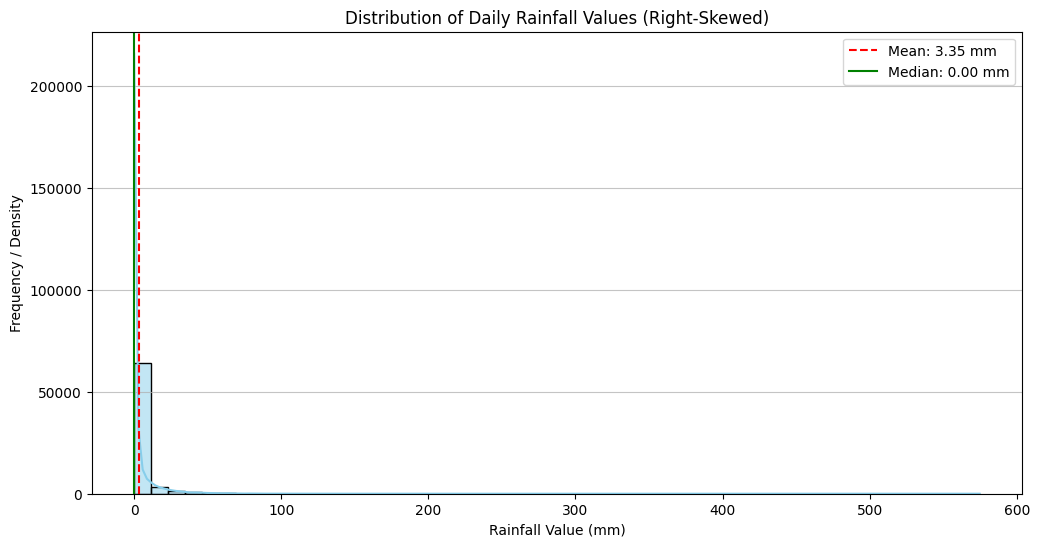

Mean Daily Rainfall: 3.35 mm
Median Daily Rainfall: 0.00 mm


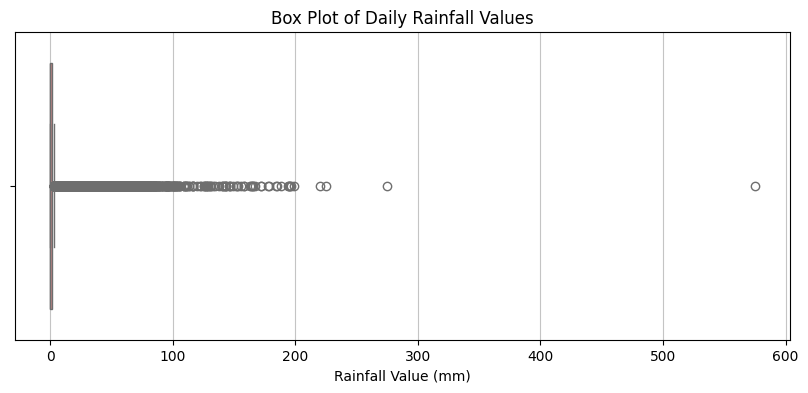

In [249]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter out zero rainfall values for a clearer view of non-zero distribution, if necessary
# Or plot all values to show the high frequency of zero rainfall

# Let's plot the full distribution including zeros to show the 'low or zero' aspect
plt.figure(figsize=(12, 6))
sns.histplot(rain_filled['rainfall_value'], bins=50, kde=True, color='skyblue')

# Calculate mean and median
mean_rainfall = rain_filled['rainfall_value'].mean()
median_rainfall = rain_filled['rainfall_value'].median()

# Add vertical lines for mean and median
plt.axvline(mean_rainfall, color='red', linestyle='--', label=f'Mean: {mean_rainfall:.2f} mm')
plt.axvline(median_rainfall, color='green', linestyle='-', label=f'Median: {median_rainfall:.2f} mm')

plt.title('Distribution of Daily Rainfall Values (Right-Skewed)')
plt.xlabel('Rainfall Value (mm)')
plt.ylabel('Frequency / Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Mean Daily Rainfall: {mean_rainfall:.2f} mm")
print(f"Median Daily Rainfall: {median_rainfall:.2f} mm")

# Optionally, a box plot can also effectively show outliers and skewness
plt.figure(figsize=(10, 4))
sns.boxplot(x=rain_filled['rainfall_value'], color='lightcoral')
plt.title('Box Plot of Daily Rainfall Values')
plt.xlabel('Rainfall Value (mm)')
plt.grid(axis='x', alpha=0.75)
plt.show()

#ข้อ7 คำนวณผลรวมปริมาณน้ำฝนรายเดือน

In [213]:
import pandas as pd

df = rain_filled.copy()
df['date'] = pd.to_datetime(df['date'])

In [214]:
monthly_rain = (
    df
    .assign(
        year=df['date'].dt.year,
        month=df['date'].dt.month
    )
    .groupby(['tele_station_oldcode', 'year', 'month'])['rainfall_value']
    .sum()
    .reset_index()
    .rename(columns={
        'tele_station_oldcode': 'node',
        'rainfall_value': 'rain'
    })
)


In [215]:
monthly_rain = monthly_rain.sort_values(
    ['node', 'year', 'month']
).reset_index(drop=True)
monthly_rain

,node,year,month,rain
0,ACRU,2025,7,83.0
1,ACRU,2025,8,164.8
2,ACRU,2025,9,248.6
3,ACRU,2025,10,48.4
4,ACRU,2025,11,52.2
...,...,...,...,...
2293,YOM012,2025,8,149.8
2294,YOM012,2025,9,256.0
2295,YOM012,2025,10,30.0
2296,YOM012,2025,11,100.6


In [224]:
import pandas as pd

df = rain_filled.copy()
df['date'] = pd.to_datetime(df['date'])

result = (
    df
    .assign(
        year=df['date'].dt.year,
        month=df['date'].dt.month
    )
    .groupby(['tele_station_oldcode', 'year', 'month'])['rainfall_value']
    .sum()
    .reset_index()
    .rename(columns={
        'tele_station_oldcode': 'Node',
        'rainfall_value': 'rain'
    })
    [['Node', 'rain', 'month', 'year']]   # จัดลำดับคอลัมน์
    .sort_values(['Node', 'year', 'month'])
    .reset_index(drop=True)
)

In [230]:
result.head(17)

,Node,rain,month,year
0,ACRU,83.0,7,2025
1,ACRU,164.8,8,2025
2,ACRU,248.6,9,2025
3,ACRU,48.4,10,2025
4,ACRU,52.2,11,2025
5,ACRU,0.2,12,2025
6,BBHN,391.6,7,2025
7,BBHN,641.2,8,2025
8,BBHN,517.6,9,2025
9,BBHN,198.8,10,2025


In [228]:
result.tail(2)

,Node,rain,month,year
2296,YOM012,100.6,11,2025
2297,YOM012,8.0,12,2025


In [229]:
import pandas as pd

pd.concat([
    result.head(16),
    result.tail(2)
])

,Node,rain,month,year
0,ACRU,83.0,7,2025
1,ACRU,164.8,8,2025
2,ACRU,248.6,9,2025
3,ACRU,48.4,10,2025
4,ACRU,52.2,11,2025
5,ACRU,0.2,12,2025
6,BBHN,391.6,7,2025
7,BBHN,641.2,8,2025
8,BBHN,517.6,9,2025
9,BBHN,198.8,10,2025


In [231]:
import os

# Capture the concatenated DataFrame into a variable
output_df = pd.concat([
    result.head(16),
    result.tail(2)
])

# Define the output directory and filename
output_dir = '/content/drive/MyDrive/Midterm 663020278-5'
output_filename = 'outout_monthly_rainfall_663020278-5.csv' # You can change this name if you prefer
output_path = os.path.join(output_dir, output_filename)

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the DataFrame to a CSV file
output_df.to_csv(output_path, index=False)

print(f"ไฟล์ '{output_filename}' ได้ถูกบันทึกที่ '{output_path}' เรียบร้อยแล้วค่ะ")

ไฟล์ 'outout_monthly_rainfall_663020278-5.csv' ได้ถูกบันทึกที่ '/content/drive/MyDrive/Midterm 663020278-5/outout_monthly_rainfall_663020278-5.csv' เรียบร้อยแล้วค่ะ


#สิ่งที่ต้องส่ง
GDrive : [https://drive.google.com/drive/folders/19y3GJEmDca7DPkZA3nLQVlKz3FKP156D?usp=sharing](https://drive.google.com/drive/folders/19y3GJEmDca7DPkZA3nLQVlKz3FKP156D?usp=sharing)

Output CSV : [https://drive.google.com/file/d/1t1UqOGp3T4VOLM42KUFLXwXM6DAfSTw4/view?usp=sharing](https://drive.google.com/file/d/1t1UqOGp3T4VOLM42KUFLXwXM6DAfSTw4/view?usp=sharing)

Prompt : [https://docs.google.com/document/d/1tJUuVxEKMWkxJVw1pvJKPsY6f4NSbcJJHDe3EGEyEoc/edit?usp=sharing](https://docs.google.com/document/d/1tJUuVxEKMWkxJVw1pvJKPsY6f4NSbcJJHDe3EGEyEoc/edit?usp=sharing)

